In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import shap
import joblib

In [2]:
model = joblib.load("../models/churn_model.pkl")

In [3]:
rfm = pd.read_csv("../data/processed/customer_features.csv")

rfm["Churn"] = np.where(
    rfm["Recency"] > 90,
    1,
    0
)

In [4]:
X = rfm[[
    "Recency",
    "Frequency",
    "Monetary"
]]

y = rfm["Churn"]

In [5]:
explainer = shap.TreeExplainer(model)

In [6]:
shap_values = explainer.shap_values(X)

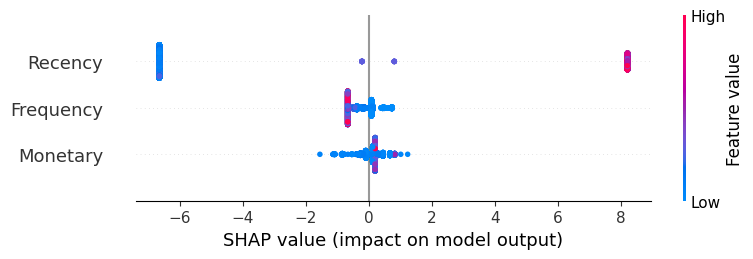

In [7]:
shap.summary_plot(
    shap_values,
    X
)

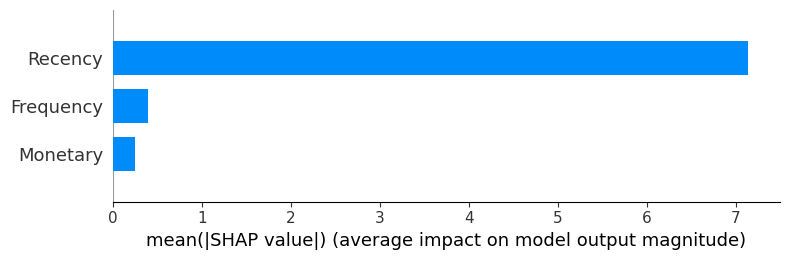

In [8]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

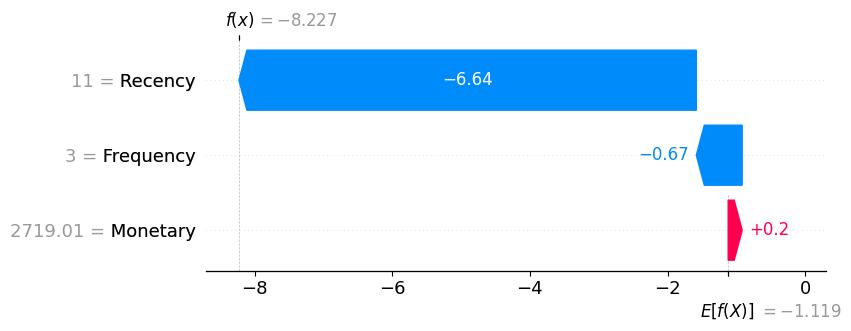

In [9]:
sample = 10

shap.plots.waterfall(
    explainer(X.iloc[[sample]])[0]
)

In [10]:
plt.savefig(
    "../reports/shap_summary.png",
    dpi=300
)

<Figure size 640x480 with 0 Axes>

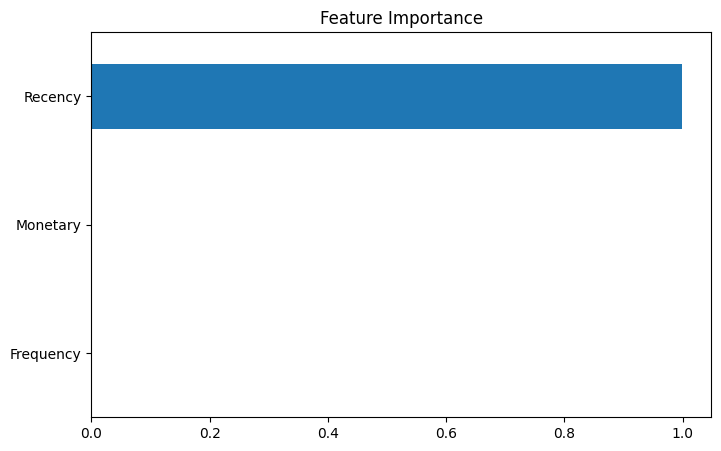

In [11]:
importance = pd.Series(

    model.feature_importances_,

    index=X.columns

)

importance.sort_values().plot(

    kind="barh",

    figsize=(8,5)

)

plt.title("Feature Importance")

plt.show()

In [12]:
new_data = X.copy()

new_data["Monetary"] *= 1.15

In [13]:
comparison = pd.DataFrame({

    "Training Mean": X.mean(),

    "New Mean": new_data.mean(),

    "Difference": new_data.mean()-X.mean()

})

comparison

,Training Mean,New Mean,Difference
Recency,91.171846,91.171846,0.000000
Frequency,4.455705,4.455705,0.000000
Monetary,2040.406712,2346.467719,306.061007


In [14]:
comparison.to_csv(

    "../reports/drift_report.csv"

)